In [109]:
#from google.colab import drive
#drive.mount('/content/drive')

In [110]:
import sys
#sys.path.append(r"C:\Users\Michael Ocampo\Documents\P_Files\opensees\final_\functions")
sys.path.append(r"C:\Users\micha\OneDrive\Documents\Python Scripts\open_sees\final_\functions")

In [111]:
#!sudo apt update
#!sudo apt install libglu1-mesa libglu1-mesa-dev
#!pip install -r requirements.txt

In [112]:
import openseespy.opensees as ops
import opsvis as opsv
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
import time
import gmsh
import solver_function as SF
import materialParam as param
import RCs_section as RCS
import importlib
importlib.reload(SF)
importlib.reload(param)
importlib.reload(RCS)
from solver_function import *
from materialParam import *
from RCs_section import *

In [113]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (126768595813)>


In [114]:
#
# Model with 9-4-quad-UP element and PDMY03 material
# By: Arash Khosravifar   January 2009
# Last edit:              August 2018
#

ops.wipe()
# There is no 'wipe all' in OpenSeesPy, ops.wipe() is sufficient.
startT = time.time()

######################### MAIN USER INPUTS #################################
matTag = 55  # 1 for (N1)60=35, 2 for (N1)60=25, 3 for (N1)60=15 and 4 for (N1)60=5 , 5 for Custom
vertPress = 1.0 * 100  # kPa vertical confining pressure
loadbias = 0.3  # Alpha = tau_xy/s'vo
Analysis_case = "drained_monotonic"
# Options:
# undrained_cyclic
# undrained_monotonic: define target max shear strain
# drained_cyclic: applies 2 cycles for each strain (9 shear strain ranging from 0.0003% to 3%) for the purpose of G/Gmax and Damping curves
# drained_monotonic: define target max shear strain
######################### END OF MAIN USER INPUTS ###########################

# Load material properties from an external file
# In Python, this is done by importing the module or executing the script.
# Assuming the TCL file is converted to a Python file named DSS_material_properties.py
try:
    exec(open('DSS_material_properties.py').read())
except FileNotFoundError:
    print("Error: The file DSS_material_properties.py was not found.")
    exit()

# Some variables for the ELEMENT
fluidDen = 1.0  # Fluid mass density
waterbulk = 2.2e6  # kPa
kdrain = 1.0e1  # permeability for drained loading
kundrain = 1.0e-8  # permeability for undrained loading
gravY = 0.0
gravX = 0.0

# Some loading related variables
if Analysis_case == "undrained_cyclic":
    target_shear_strain = 3.0 / 100.0
    csr = 0.45
    period = 1.0
    deltaT = 0.005
    kPerm = kundrain
elif Analysis_case == "undrained_monotonic":
    target_shear_strain = 3.0 / 100.0
    period = 1.0
    deltaT = 0.005
    numSteps = 200
    kPerm = kundrain
    # also change penalty from 1e15 and 1e5 for sand to clay
elif Analysis_case == "drained_monotonic":
    # also change the damping to 0.005
    target_shear_strain = 1.0 / 100.0  # unit in strain - it will be multiplied by ySize later. Note: DON'T forget the ".0" in 1.0
    period = 1.0
    deltaT = 0.005
    numSteps = 3000
    kPerm = kdrain
    phaseTransAng = frictionAng
    contraction_a = 0.0
    contraction_b = 0.0
    contraction_c = 0.0
    contraction_d = 0.0
    contraction_e = 0.0
    dilation_a = 0.0
    dilation_b = 0.0
    dilation_c = 0.0
    liqParam1 = 0.0
    liqParam2 = 0.0
elif Analysis_case == "drained_cyclic":
    period = 10.0
    deltaT = 0.005
    numSteps = 4000
    kPerm = kdrain
    phaseTransAng = frictionAng
    contraction_a = 0.0
    contraction_b = 0.0
    contraction_c = 0.0
    contraction_d = 0.0
    contraction_e = 0.0
    dilation_a = 0.0
    dilation_b = 0.0
    dilation_c = 0.0
    liqParam1 = 0.0
    liqParam2 = 0.0

# Define Rayleigh Damping
rayleigh_damping1 = 0.001
rayleigh_damping2 = 0.001
rayleigh_w1 = 2 * math.pi / period
rayleigh_w2 = 2 * math.pi / (period / 2.0)
Kinitproprayleigh = 2.0 * rayleigh_w1 * rayleigh_w2 / (rayleigh_w1 * rayleigh_w1 - rayleigh_w2 * rayleigh_w2) * (-1.0 * rayleigh_damping1 / rayleigh_w1 + 1.0 * rayleigh_damping2 / rayleigh_w2)
Mproprayleigh = 2.0 * rayleigh_w1 * rayleigh_w2 / (rayleigh_w1 * rayleigh_w1 - rayleigh_w2 * rayleigh_w2) * (rayleigh_damping1 * rayleigh_w1 - rayleigh_damping2 * rayleigh_w2)

####################################################################
xsize = 0.1
ysize = 0.1
thickness = 0.1

# define the 3DOF nodes
ops.model('basic', '-ndm', 2, '-ndf', 3)
ops.node(1, 0.0, 0.0)
ops.node(2, xsize, 0.0)
ops.node(3, xsize, ysize)
ops.node(4, 0.0, ysize)

ops.fix(1, 1, 1, 0)
ops.fix(2, 1, 1, 0)
ops.fix(3, 0, 0, 1)
ops.fix(4, 0, 0, 1)
ops.equalDOF(1, 2, 3)
ops.equalDOF(3, 4, 1, 2)

# define the 2DOF nodes
ops.model('basic', '-ndm', 2, '-ndf', 2)
ops.node(5, xsize / 2, 0.0)
ops.node(6, xsize, ysize / 2)
ops.node(7, xsize / 2, ysize)
ops.node(8, 0.0, ysize / 2)
ops.node(9, xsize / 2, ysize / 2)

ops.fix(5, 1, 1)
ops.equalDOF(3, 7, 1, 2)
ops.equalDOF(6, 8, 1, 2)
# ops.equalDOF(6, 9, 1, 2)

################# define material ##################################
ops.nDMaterial('PressureDependMultiYield03', matTag, 2, massDen, refG, refB, frictionAng,
               peakShearStrain, refPress, pressDependCoe, phaseTransAng,
               0, contraction_a, contraction_b, contraction_c, contraction_d, contraction_e,
               dilation_a, dilation_b, dilation_c,
               noYieldSurf, liqParam1, liqParam2,
               pa, S0)

####################################################################
# define the element                     thick       maTag  bulk         fmass      hPerm   vPerm
ops.element('9_4_QuadUP', 1, 1, 2, 3, 4, 5, 6, 7, 8, 9, thickness, matTag, waterbulk / 0.4, fluidDen, kPerm, kPerm, gravX, gravY)

####################################################################
# Recorders
if not os.path.exists("output"):
    os.mkdir("output")

ops.recorder('Node', '-file', f"output/disp1_{Analysis_case}.out", '-time', '-node', 1, 2, 3, 4, 5, 6, 7, 8, 9, '-dof', 1, 'disp')
ops.recorder('Node', '-file', f"output/disp2_{Analysis_case}.out", '-time', '-node', 1, 2, 3, 4, 5, 6, 7, 8, 9, '-dof', 2, 'disp')
ops.recorder('Node', '-file', f"output/pwp_{Analysis_case}.out", '-time', '-node', 1, 2, 3, 4, '-dof', 3, 'vel')
ops.recorder('Element', '-file', f"output/stress_{Analysis_case}.out", '-time', '-ele', 1, 'material', 9, 'stress')  # s11 s22 s33 s12 eta (EFFECTIVE stresses)
ops.recorder('Element', '-file', f"output/strain_{Analysis_case}.out", '-time', '-ele', 1, 'material', 9, 'strain')  # e11 e22 gama12 (it is not e33 nor e12)
ops.recorder('Element', '-file', f"output/backbone_{Analysis_case}.out", '-ele', 1, 'material', 9, 'backbone', 100, 1600)

####################################################################
# GRAVITY APPLICATION (elastic behavior)
ops.model('basic', '-ndm', 2, '-ndf', 3)
ops.timeSeries('Constant', 1)
ops.pattern('Plain', 1, 1)
ops.load(3, loadbias * vertPress * xsize * thickness * 0.25, -vertPress * xsize * thickness * 0.25, 0)
ops.load(4, loadbias * vertPress * xsize * thickness * 0.25, -vertPress * xsize * thickness * 0.25, 0)

ops.model('basic', '-ndm', 2, '-ndf', 2)
ops.timeSeries('Constant', 2)
ops.pattern('Plain', 2, 2)
ops.load(7, loadbias * vertPress * xsize * thickness * 0.5, -vertPress * xsize * thickness * 0.5)

ops.numberer('RCM')
ops.system('ProfileSPD')
ops.test('NormDispIncr', 1.0e-5, 50, 2)
ops.constraints('Plain')  # Penalty 1.e18 1.e18
ops.rayleigh(1.0 * Mproprayleigh, 0.0, Kinitproprayleigh, 0.0)
gama = 1.5
betta = (gama + 0.5)**2 / 4
ops.integrator('Newmark', gama, betta)
ops.algorithm('KrylovNewton')
ops.analysis('VariableTransient')

ops.updateMaterialStage('-material', matTag, '-stage', 0)
for i in range(1, 101):
    ops.analyze(1, 1000)
    tCurrent = ops.getTime()
    print(f"time = {tCurrent} sec")
for i in range(1, 101):
    ops.analyze(1, 1000)
    tCurrent = ops.getTime()
    print(f"time = {tCurrent} sec")
print("Done Elastic")
ops.updateMaterialStage('-material', matTag, '-stage', 1)

for i in range(1, 101):
    ops.analyze(1, 100)
    tCurrent = ops.getTime()
    print(f"time = {tCurrent} sec")

for i in range(1, 201):
    ops.analyze(1, 1000)
    tCurrent = ops.getTime()
    print(f"time = {tCurrent} sec")
print("Done Plastic")
print("Gravity Done!")

####################################################################
# Adjust some fixities for shear loading
# remove surface pwp fixity
ops.model('basic', '-ndm', 2, '-ndf', 3)
ops.remove('sp', 3, 3)
ops.remove('sp', 4, 3)
ops.equalDOF(3, 4, 3)

####################################################################
ops.loadConst('-time', 0.0)
ops.wipeAnalysis()

####################################################################
# NOW APPLY LOADING SEQUENCE AND ANALYZE (plastic)
# Load control cyclic
if Analysis_case == "undrained_cyclic":
    # Define analysis parameters
    ops.numberer('RCM')
    ops.system('ProfileSPD')
    ops.test('NormDispIncr', 1.0e-5, 50, 0)
    ops.constraints('Plain')
    ops.rayleigh(Mproprayleigh, 0.0, Kinitproprayleigh, 0.0)
    gama = 1.5
    betta = (gama + 0.5)**2 / 4
    ops.integrator('Newmark', gama, betta)
    ops.algorithm('KrylovNewton')
    ops.analysis('VariableTransient')

    ops.model('basic', '-ndm', 2, '-ndf', 3)
    ops.timeSeries('Sine',4, 0, period * 1000, period)
    ops.pattern('Plain', 4, 4)
    ops.load(3, csr * vertPress * xsize * thickness * 0.25, 0, 0)
    ops.load(4, csr * vertPress * xsize * thickness * 0.25, 0, 0)
    ops.model('basic', '-ndm', 2, '-ndf', 2)
    ops.timeSeries('Sine',5, 0, period * 1000, period)
    ops.pattern('Plain', 5, 5)
    ops.load(7, csr * vertPress * xsize * thickness * 0.5, 0)

    print(Analysis_case)
    while abs(ops.nodeDisp(7, 1) / ysize) < target_shear_strain:
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        print(f"time = {ops.getTime()} sec")

# Disp control monotonic
elif Analysis_case == "undrained_monotonic":
    # Define analysis parameters
    ops.numberer('RCM')
    ops.system('BandGeneral')
    ops.test('NormDispIncr', 1.0e-5, 50, 0)
    ops.constraints('Penalty', 1.0e10, 1.0e10)
    ops.rayleigh(Mproprayleigh, 0.0, Kinitproprayleigh, 0.0)
    gama = 1.5
    betta = (gama + 0.5)**2 / 4
    ops.integrator('Newmark', gama, betta)
    ops.algorithm('KrylovNewton')
    ops.analysis('VariableTransient')

    ops.model('basic', '-ndm', 2, '-ndf', 2)
    ops.timeSeries('Linear', 14)
    ops.pattern('Plain', 14, 14)
    ops.sp(3, 1, ysize * target_shear_strain)
    ops.sp(4, 1, ysize * target_shear_strain)
    ops.sp(7, 1, ysize * target_shear_strain)

    print(Analysis_case)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")

# Disp control monotonic
elif Analysis_case == "drained_monotonic":
    # Define analysis parameters
    ops.numberer('RCM')
    ops.system('BandGeneral')
    ops.test('NormDispIncr', 1.0e-5, 50, 0)
    ops.constraints('Penalty', 1.0e18, 1.0e18)
    ops.rayleigh(Mproprayleigh, 0.0, Kinitproprayleigh, 0.0)
    gama = 1.5
    betta = (gama + 0.5)**2 / 4
    ops.integrator('Newmark', gama, betta)
    ops.algorithm('KrylovNewton')
    ops.analysis('VariableTransient')

    ops.model('basic', '-ndm', 2, '-ndf', 3)
    ops.timeSeries('Linear', 15)
    ops.pattern('Plain', 15, 15)
    ops.sp(3, 1, ysize * target_shear_strain)
    ops.sp(4, 1, ysize * target_shear_strain)
    ops.sp(7, 1, ysize * target_shear_strain)

    print(Analysis_case)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")

# Disp control cyclic for G/Gmax and Xi curves
elif Analysis_case == "drained_cyclic":
    # Define analysis parameters
    ops.numberer('RCM')
    ops.system('BandGeneral')
    ops.test('NormDispIncr', 1.0e-5, 50, 0)
    ops.constraints('Penalty', 1.0e18, 1.0e18)
    ops.rayleigh(Mproprayleigh, 0.0, Kinitproprayleigh, 0.0)
    gama = 1.5
    betta = (gama + 0.5)**2 / 4
    ops.integrator('Newmark', gama, betta)
    ops.algorithm('KrylovNewton')
    ops.analysis('VariableTransient')

    ops.model('basic', '-ndm', 2, '-ndf', 2)
    ops.timeSeries('Sine',4, 0, 1000, period)
    ops.pattern('Plain', 4, 4)
    ops.sp(3, 1, ysize * 0.0003 / 100.0)

    print(Analysis_case)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
    ops.remove('loadPattern', 4)
    ops.loadConst()
    ops.timeSeries('Sine',5, 0, 1000, period)
    ops.pattern('Plain', 5, 5)
    ops.sp(3, 1, ysize * 0.001 / 100.0)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
    ops.remove('loadPattern', 5)
    ops.loadConst()
    ops.timeSeries('Sine', 6, 0, 1000, period)
    ops.pattern('Plain', 6, 6)
    ops.sp(3, 1, ysize * 0.003 * 0.01)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
    ops.remove('loadPattern', 6)
    ops.loadConst()
    ops.timeSeries('Sine',7, 0, 1000, period)
    ops.pattern('Plain', 7, 7)
    ops.sp(3, 1, ysize * 0.01 * 0.01)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
    ops.remove('loadPattern', 7)
    ops.loadConst()
    ops.timeSeries('Sine',8, 0, 1000, period)
    ops.pattern('Plain', 8, 8)
    ops.sp(3, 1, ysize * 0.03 * 0.01)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
    ops.remove('loadPattern', 8)
    ops.loadConst()
    ops.timeSeries('Sine',9, 0, 1000, period)
    ops.pattern('Plain', 9, 9)
    ops.sp(3, 1, ysize * 0.1 * 0.01)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
    ops.remove('loadPattern', 9)
    ops.loadConst()
    ops.timeSeries('Sine', 10, 0, 1000, period)
    ops.pattern('Plain', 10, 10)
    ops.sp(3, 1, ysize * 0.3 * 0.01)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
    ops.remove('loadPattern', 10)
    ops.loadConst()
    ops.timeSeries('Sine',11, 0, 1000, period)
    ops.pattern('Plain', 11, 11)
    ops.sp(3, 1, ysize * 1.0 * 0.01)
    for i in range(1, numSteps + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
    ops.remove('loadPattern', 11)
    ops.loadConst()
    ops.timeSeries('Sine',12, 0, 1000, period)
    ops.pattern('Plain', 12,12 )
    ops.sp(3, 1, ysize * 3.0 * 0.01)
    for i in range(1, int(numSteps * 1.25) + 1):
        ops.analyze(1, deltaT, deltaT / 100, deltaT, 20)
        tCurrent = ops.getTime()
        print(f"time = {tCurrent} sec")
####################################################################
endT = time.time()
print(f"Execution time: {endT - startT} seconds.")#
print("Finished with cyclic loading")
ops.wipe()
# The 'wipe all' and 'wipe' at the end are redundant since ops.wipe() clears everything.

time = 1000.0 sec
time = 2000.0 sec
time = 3000.0 sec
time = 4000.0 sec
time = 5000.0 sec
time = 6000.0 sec
time = 7000.0 sec
time = 8000.0 sec
time = 9000.0 sec
time = 10000.0 sec
time = 11000.0 sec
time = 12000.0 sec
time = 13000.0 sec
time = 14000.0 sec
time = 15000.0 sec
time = 16000.0 sec
time = 17000.0 sec
time = 18000.0 sec
time = 19000.0 sec
time = 20000.0 sec
time = 21000.0 sec
time = 22000.0 sec
time = 23000.0 sec
time = 24000.0 sec
time = 25000.0 sec
time = 26000.0 sec
time = 27000.0 sec
time = 28000.0 sec
time = 29000.0 sec
time = 30000.0 sec
time = 31000.0 sec
time = 32000.0 sec
time = 33000.0 sec
time = 34000.0 sec
time = 35000.0 sec
time = 36000.0 sec
time = 37000.0 sec
time = 38000.0 sec
time = 39000.0 sec
time = 40000.0 sec
time = 41000.0 sec
time = 42000.0 sec
time = 43000.0 sec
time = 44000.0 sec
time = 45000.0 sec
time = 46000.0 sec
time = 47000.0 sec
time = 48000.0 sec
time = 49000.0 sec
time = 50000.0 sec
time = 51000.0 sec
time = 52000.0 sec
time = 53000.0 sec
ti

CTestNormDispIncr::test() - iteration: 2 current Norm: 3.74066e-20 (max: 1e-05, Norm deltaR: 3.57372e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 1.15848e-11 (max: 1e-05, Norm deltaR: 3.32026e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 2.89621e-12 (max: 1e-05, Norm deltaR: 4.62825e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 1.22312e-18 (max: 1e-05, Norm deltaR: 2.9637e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 1.56549e-19 (max: 1e-05, Norm deltaR: 2.63678e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 1.03841e-20 (max: 1e-05, Norm deltaR: 1.07497e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 1.2036e-21 (max: 1e-05, Norm deltaR: 1.07497e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 1.20351e-21 (max: 1e-05, Norm deltaR: 1.07497e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 1.20351e-21 (max: 1e-05, Norm deltaR: 1.07497e-16)
CTestNormDispIncr::test() - iteration: 1 current

time = 0.2650000000000001 sec
time = 0.27000000000000013 sec
time = 0.27500000000000013 sec
time = 0.28000000000000014 sec
time = 0.28500000000000014 sec
time = 0.29000000000000015 sec
time = 0.29500000000000015 sec
time = 0.30000000000000016 sec
time = 0.30500000000000016 sec
time = 0.31000000000000016 sec
time = 0.31500000000000017 sec
time = 0.3200000000000002 sec
time = 0.3250000000000002 sec
time = 0.3300000000000002 sec
time = 0.3350000000000002 sec
time = 0.3400000000000002 sec
time = 0.3450000000000002 sec
time = 0.3500000000000002 sec
time = 0.3550000000000002 sec
time = 0.3600000000000002 sec
time = 0.3650000000000002 sec
time = 0.3700000000000002 sec
time = 0.3750000000000002 sec
time = 0.3800000000000002 sec
time = 0.38500000000000023 sec
time = 0.39000000000000024 sec
time = 0.39500000000000024 sec
time = 0.40000000000000024 sec
time = 0.40500000000000025 sec
time = 0.41000000000000025 sec
time = 0.41500000000000026 sec
time = 0.42000000000000026 sec
time = 0.4250000000000

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
del min
# -----------------------------------------------------------------------------
# Post-processor converted and cleaned from MATLAB
# - Safe indexing (MATLAB->Python 1-based -> 0-based)
# - Avoids shadowing builtins (uses np.minimum/np.maximum)
# - Robust file loading with clear errors
# - Defensive index checks and fallbacks
# - Handles all four analysis cases
# -----------------------------------------------------------------------------

# -------------------------- Configuration ------------------------------------
# Options: 'undrained_cyclic', 'undrained_monotonic', 'drained_cyclic', 'drained_monotonic'
#Analysis_case = 'undrained_cyclic'
input_dir = Path('output')
consol_step = 500  # as in the MATLAB code (1-based). We'll compute 0-based index below.

# -------------------------- Helpers ------------------------------------------

def load_txt(path: Path) -> np.ndarray:
    """Load whitespace-delimited text file with numpy; give clear message on failure."""
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    return np.loadtxt(path)


def safe_idx(arr: np.ndarray, idx: int, fallback: int = 0) -> int:
    """Return idx if in bounds else a fallback index (clamped)."""
    if idx < 0:
        return 0
    if idx >= arr.shape[0]:
        return arr.shape[0] - 1
    return idx

def idx_clamped(i: int, arr: np.ndarray) -> int:
    return int(np.clip(i, 0, arr.shape[0] - 1))

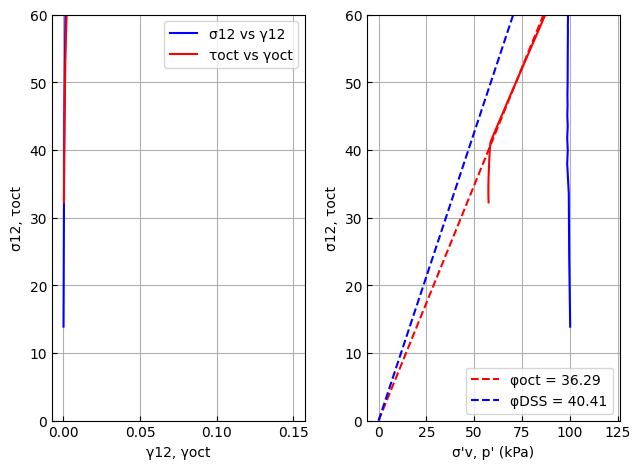

In [116]:
# --------------------------------------------------
# 2. Load Data
# --------------------------------------------------
input_disp1 = np.loadtxt(f"output/disp1_{Analysis_case}.out")
input_disp2 = np.loadtxt(f"output/disp2_{Analysis_case}.out")
input_stress = np.loadtxt(f"output/stress_{Analysis_case}.out")
input_strain = np.loadtxt(f"output/strain_{Analysis_case}.out")
input_pwp = np.loadtxt(f"output/pwp_{Analysis_case}.out")
input_backbone = np.loadtxt(f"output/backbone_{Analysis_case}.out")

# --------------------------------------------------
# 3. Preprocessing
# --------------------------------------------------
# Displacements
Disp_1 = input_disp1[:, 1:]
Disp_2 = input_disp2[:, 1:]

# Stresses (compression:+, tension:-)
s_11 = -input_stress[:, 1]
s_22 = -input_stress[:, 2]
s_33 = -input_stress[:, 3]
s_12 = input_stress[:, 4]
eta = input_stress[:, 5]

# Octahedral shear stress
tau_oct = (1 / 3) * np.sqrt((s_11 - s_22) ** 2 + (s_11 - s_33) ** 2 + (s_22 - s_33) ** 2 + 6 * s_12 ** 2)
q = (3 / np.sqrt(2)) * tau_oct

# Pore water pressure
pwp = (input_pwp[:, 1] + input_pwp[:, 2] + input_pwp[:, 3] + input_pwp[:, 4]) / 4
p = (s_11 + s_22 + s_33) / 3
p_tot = p + pwp
time = input_pwp[:, 0]

# Strains (upward dilation:-, contraction:+)
e_11 = -input_strain[:, 1]
e_22 = -input_strain[:, 2]
gama_12 = input_strain[:, 3]
e_33 = np.zeros_like(e_11)
e_v = e_11 + e_22 + e_33
gama_oct = (2 / 3) * np.sqrt((e_11 - e_22) ** 2 + (e_22 - e_33) ** 2 + (e_11 - e_33) ** 2 + 6 * (gama_12 / 2) ** 2)

# CSL line
cs1, cs2, cs3 = 0.9, 0.1, 1.0
void_i = 0.8
void = void_i - e_22 * (1 + void_i)

# Consolidation steps
consol_step = 500
total_step = len(gama_12)

# Ru ratios
ru_1 = pwp / np.maximum(p, 0.001)
ru_2 = pwp / p[consol_step]
ru_3 = pwp / s_22[consol_step]

# --------------------------------------------------
# 4. Cases
# --------------------------------------------------
if Analysis_case == "drained_cyclic":
    period = 10
    cycle = time / period

    NoStepsCycle = 2000
    NoCycleEach = 2
    corr_steps = np.arange(
        consol_step + NoStepsCycle // 4,
        consol_step + 9 * NoStepsCycle * NoCycleEach + 1,
        NoStepsCycle * NoCycleEach,
        dtype=int,
    )

    G_sec = s_12[corr_steps] / gama_12[corr_steps]
    G_max = s_12[consol_step] / gama_12[consol_step]
    G_max_oct = tau_oct[consol_step] / gama_oct[consol_step]

    # EPRI 1993 data
    #GratioEPRI6 = np.array([1, 0.98, 0.919, 0.751, 0.519, 0.271, 0.121, 0.045, 0.024])
    #GratioEPRI76 = np.array([1, 0.999, 0.982, 0.9, 0.752, 0.502, 0.282, 0.124, 0.07])
    #gama_EPRI = np.array([3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2])

    Xi = []
    for idx in corr_steps:
        start, end = idx, idx + NoStepsCycle
        hysteresis = np.trapz(s_12[start:end], gama_12[start:end])
        triangle = 0.5 * gama_12[start] * s_12[start]
        Xi.append(hysteresis / (4 * np.pi * triangle) * 100 if triangle != 0 else 0)
    Xi = np.array(Xi)

    #XiEPRI6 = np.array([0.791, 1.27, 2.28, 4.26, 7.75, 14.74, 22.03, 27.12, 30.21])
    #XiEPRI76 = np.array([0.591, 0.88, 1.271, 2.46, 4.551, 8.34, 14.13, 21.22, 25.31])

    # Plots
    plt.figure()
    plt.semilogx(gama_12[corr_steps], G_sec / G_max, "-ob", linewidth=2, label="PDMY03 - σ'vo=100 KPa")
    #plt.semilogx(gama_EPRI, GratioEPRI6, "--r", linewidth=2, label="EPRI1993 0-6m")
    #plt.semilogx(gama_EPRI, GratioEPRI76, "--r", linewidth=2, label="EPRI1993 36-76m")
    plt.xlabel("γ12")
    plt.ylabel("Gsec/Gmax")
    plt.legend()
    plt.grid(True)

    plt.figure()
    plt.semilogx(gama_12[corr_steps], Xi, "-ob", linewidth=2, label="PDMY03 - σ'vo=100 KPa")
    #plt.semilogx(gama_EPRI, XiEPRI6, "--r", linewidth=2, label="EPRI1993 0-6m")
    #plt.semilogx(gama_EPRI, XiEPRI76, "--r", linewidth=2, label="EPRI1993 36-76m")
    plt.xlabel("γ12")
    plt.ylabel("Damping ratio (%)")
    plt.legend()
    plt.grid(True)

    plt.figure()
    plt.subplot(2, 1, 1)
    plt.plot(gama_12, s_12 / s_22[consol_step], "b")
    plt.ylabel("CSR = σ12/σ'vc")
    plt.xlabel("γ12")
    plt.title(f"σ'vc = {s_22[consol_step]:.2f} kPa")
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(cycle[consol_step:], gama_12[consol_step:], "b")
    plt.xlabel("No. of cycles")
    plt.ylabel("γ12")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

elif Analysis_case == "undrained_cyclic":
    period = 1
    cycle = time / period

    gama_consol = gama_12[consol_step]

    T_1_idx = np.where(np.abs(gama_12 - gama_consol) > 0.01)[0]
    T_1 = T_1_idx[0] if T_1_idx.size > 0 else consol_step
    N_1 = cycle[T_1]

    T_3_idx = np.where(np.abs(gama_12 - gama_consol) > 0.03)[0]
    T_3 = T_3_idx[0] if T_3_idx.size > 0 else consol_step
    N_3 = cycle[T_3]

    T_r_idx = np.where(ru_3 > 0.98)[0]
    T_r = T_r_idx[0] if T_r_idx.size > 0 else consol_step
    N_r = cycle[T_r]

    print(f"N1 = {N_1}, N3 = {N_3}, Nr = {N_r}")

    plt.figure()
    plt.subplot(2, 2, 1)
    plt.plot(gama_12, s_12 / s_22[consol_step], "b")
    plt.plot(gama_12[T_1], s_12[T_1] / s_22[consol_step], "g.", markersize=15)
    plt.plot(gama_12[T_3], s_12[T_3] / s_22[consol_step], "r.", markersize=15)
    plt.plot(gama_12[T_r], s_12[T_r] / s_22[consol_step], "m.", markersize=15)
    plt.grid(True)
    plt.xlabel("γ12")
    plt.ylabel("CSR = σ12/σ'vc")

    plt.subplot(2, 2, 2)
    ratio_s22 = s_22 / s_22[consol_step]
    plt.plot(ratio_s22, s_12 / s_22[consol_step], "b")
    plt.plot(ratio_s22[T_1], s_12[T_1] / s_22[consol_step], "g.", markersize=15)
    plt.plot(ratio_s22[T_3], s_12[T_3] / s_22[consol_step], "r.", markersize=15)
    plt.plot(ratio_s22[T_r], s_12[T_r] / s_22[consol_step], "m.", markersize=15)
    plt.xlim([min(0.0, np.min(ratio_s22)), np.max(ratio_s22)])
    plt.grid(True)
    plt.xlabel("σ'v/σ'vc")
    plt.ylabel("CSR")

    plt.subplot(2, 2, 3)
    plt.plot(cycle[consol_step:], pwp[consol_step:], "b")
    plt.plot(cycle[T_1], pwp[T_1], "g.", markersize=15)
    plt.plot(cycle[T_3], pwp[T_3], "r.", markersize=15)
    plt.plot(cycle[T_r], pwp[T_r], "m.", markersize=15)
    plt.ylabel("PWP (kPa)")
    plt.xlabel("No. of cycles")
    plt.ylim([-10, 100])
    plt.grid(True)

    plt.subplot(2, 2, 4)
    plt.plot(cycle[consol_step:], gama_12[consol_step:], "b")
    plt.xlabel("No. of cycles")
    plt.ylabel("γ12")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

elif Analysis_case == "drained_monotonic":
    G_max = s_12[consol_step] / gama_12[consol_step]
    G_max_oct = tau_oct[consol_step] / gama_oct[consol_step]

    plt.figure()
    plt.subplot(1, 2, 1)
    plt.plot(gama_12[consol_step:], s_12[consol_step:], "b", label="σ12 vs γ12")
    plt.plot(gama_oct[consol_step:], tau_oct[consol_step:], "r", label="τoct vs γoct")
    plt.xlabel("γ12, γoct")
    plt.ylabel("σ12, τoct")
    plt.ylim([0, 60])
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(p[consol_step:], tau_oct[consol_step:], "r")
    plt.plot(s_22[consol_step:], s_12[consol_step:], "b")
    plt.ylim([0, 60])
    plt.grid(True)

    slope_oct = tau_oct[-1] / p[-1]
    Phi_oct = np.degrees(np.arcsin(3 * slope_oct / (2 * np.sqrt(2) + slope_oct)))
    slope_conv = s_12[-1] / s_22[-1]
    Phi_conv = np.degrees(np.arctan(slope_conv))

    plt.plot([0, np.max(p) * 1.2], [0, (np.max(p) * 1.2) * slope_oct], "--r", label=f"φoct = {Phi_oct:.2f}")
    plt.plot([0, np.max(s_22) * 1.2], [0, (np.max(s_22) * 1.2) * slope_conv], "--b", label=f"φDSS = {Phi_conv:.2f}")
    plt.legend()
    plt.xlabel("σ'v, p' (kPa)")
    plt.ylabel("σ12, τoct")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

elif Analysis_case == "undrained_monotonic":
    plt.figure()
    plt.subplot(2, 2, 1)
    plt.plot(gama_12[consol_step:], s_12[consol_step:], "b")
    plt.xlabel("γ12")
    plt.ylabel("σ12 (kPa)")
    plt.grid(True)

    plt.subplot(2, 2, 2)
    plt.plot(s_22[consol_step:], s_12[consol_step:], "b")
    plt.plot([0, s_22[-1]], [0, s_12[-1]], "r")
    slope_conv = s_12[-1] / s_22[-1]
    Phi_conv = np.degrees(np.arctan(slope_conv))
    plt.legend([f"φDSS = {Phi_conv:.2f}"])
    plt.xlabel("σ'v (kPa)")
    plt.ylabel("σ12 (kPa)")
    plt.grid(True)

    plt.subplot(2, 2, 3)
    plt.plot(gama_12, pwp, "b")
    plt.xlabel("γ12")
    plt.ylabel("pwp (kPa)")
    plt.grid(True)

    plt.subplot(2, 2, 4)
    plt.plot(gama_12, e_v - e_v[consol_step], "b")
    plt.gca().invert_yaxis()
    plt.xlabel("γ12")
    plt.ylabel("Volumetric strain Δεv")
    plt.grid(True)

    plt.tight_layout()
    plt.show()


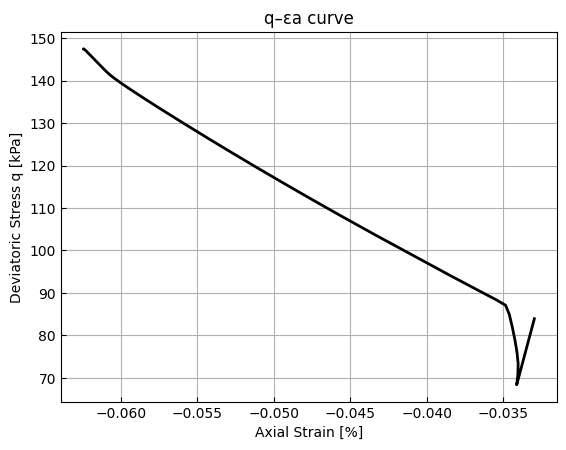

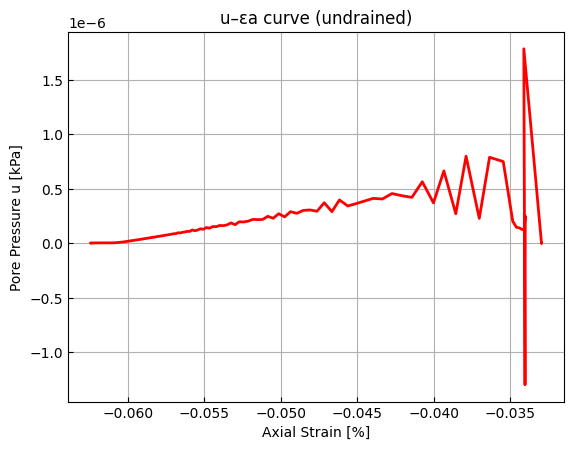

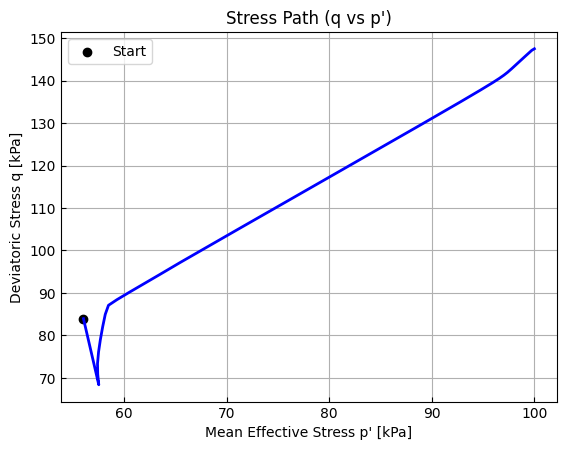

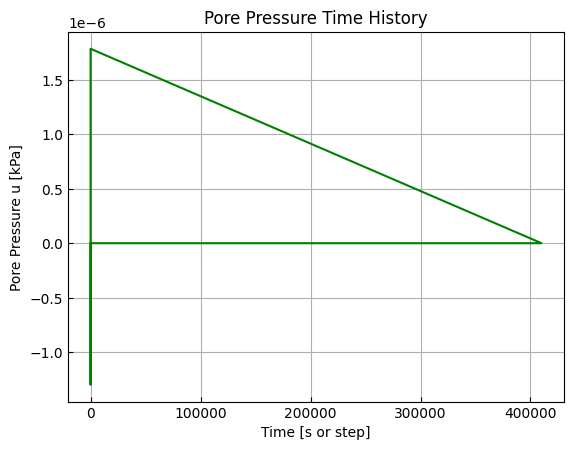

Figures saved in: figures


In [117]:
# ------------------------------------------------------------
# Plotting conventional triaxial results
# ------------------------------------------------------------
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)

# Axial strain (we take -e22 as positive axial strain %)
axial_strain = -e_22 * 100.0  # [%]

# 1) Deviatoric stress q vs axial strain
plt.figure()
plt.plot(axial_strain, q, 'k-', lw=2)
plt.xlabel("Axial Strain [%]")
plt.ylabel("Deviatoric Stress q [kPa]")
plt.title("q–εa curve")
plt.grid(True)
plt.savefig(output_dir / "q_vs_axialstrain.png", dpi=300)

# 2) Pore pressure vs axial strain
plt.figure()
plt.plot(axial_strain, pwp, 'r-', lw=2)
plt.xlabel("Axial Strain [%]")
plt.ylabel("Pore Pressure u [kPa]")
plt.title("u–εa curve (undrained)")
plt.grid(True)
plt.savefig(output_dir / "pwp_vs_axialstrain.png", dpi=300)

# 3) Stress path q–p'
plt.figure()
plt.plot(p, q, 'b-', lw=2)
plt.scatter([p[0]], [q[0]], c='k', marker='o', label='Start')
plt.xlabel("Mean Effective Stress p' [kPa]")
plt.ylabel("Deviatoric Stress q [kPa]")
plt.title("Stress Path (q vs p')")
plt.legend()
plt.grid(True)
plt.savefig(output_dir / "q_vs_p.png", dpi=300)

# 4) Time history of pore pressure (optional)
plt.figure()
plt.plot(time, pwp, 'g-', lw=1.5)
plt.xlabel("Time [s or step]")
plt.ylabel("Pore Pressure u [kPa]")
plt.title("Pore Pressure Time History")
plt.grid(True)
plt.savefig(output_dir / "pwp_vs_time.png", dpi=300)

plt.show()
print(f"Figures saved in: {output_dir}")